# Final Evaluation and Explainability
Evaluation metrics, residual plots, error slicing, and feature importance explainability.

In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Add src to path
sys.path.append('../src')

from load_data import load_raw_data
from preprocess import split_data_time_based, preprocess_data
from models import RidgeBaseline
from evaluate import calculate_metrics
from explain import get_linear_coefficients, calculate_permutation_importance

In [2]:
print("Loading and Preprocessing for Final Eval...")
df = load_raw_data()
train_df, test_df = split_data_time_based(df)
target_col = 'hpi_metro_nsa'

# Keep meta columns for slicing later
test_meta = test_df[['year', 'quarter', 'metro_name', 'period_id']].reset_index(drop=True)

train_df_scaled, test_df_scaled, scaler = preprocess_data(train_df.copy(), test_df.copy(), target_col=target_col)

cols_to_drop = ['year', 'quarter', 'metro_name', 'period_id', target_col]
X_train = train_df_scaled.drop(columns=cols_to_drop, errors='ignore')
y_train = train_df_scaled[target_col]
X_test = test_df_scaled.drop(columns=cols_to_drop, errors='ignore')
y_test = test_df_scaled[target_col]

feature_names = X_train.columns.tolist()

Loading and Preprocessing for Final Eval...


In [3]:
# Train Best Model (Ridge)
print("Training Ridge Model (Best Baseline)...")
model = RidgeBaseline(alphas=[0.01, 0.1, 1, 10])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 1. Metrics & Residuals
metrics = calculate_metrics(y_test, y_pred, "Ridge Best")
print("\nMetrics:")
print(metrics)

residuals = y_test - y_pred

Training Ridge Model (Best Baseline)...

Metrics:
{'Model': 'Ridge Best', 'MAE': 3.993785432817599, 'RMSE': np.float64(6.122874048379922), 'R2': 0.9975104285594867}


In [4]:
# Create Plots
os.makedirs('../reports/figures', exist_ok=True)

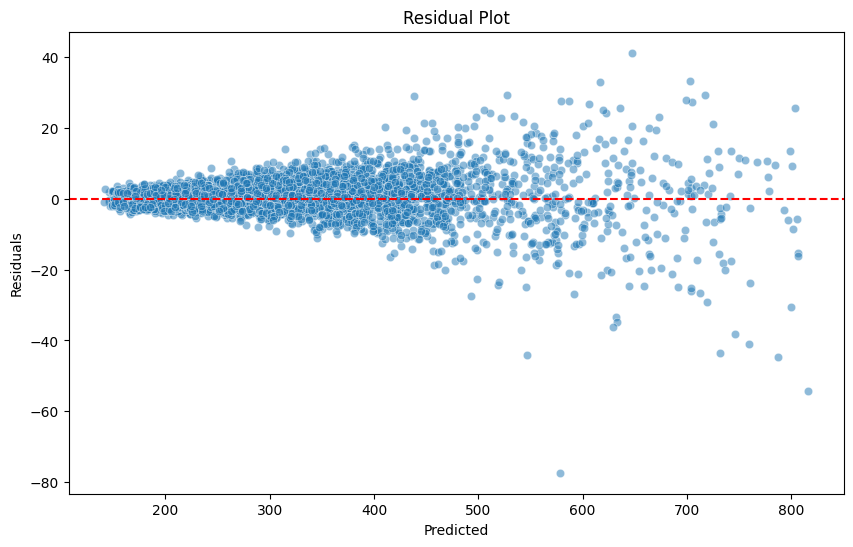

In [5]:
# A. Residual Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.savefig('../reports/figures/residual_plot.png')
plt.show()

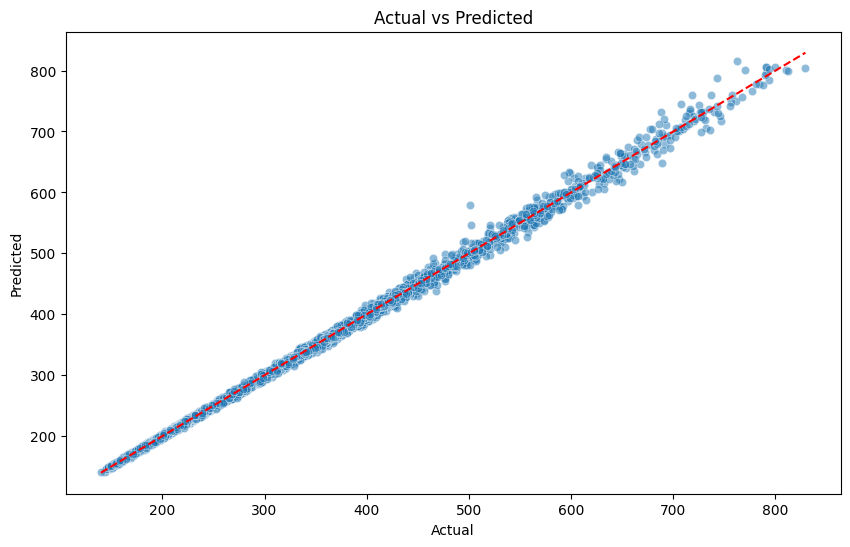

In [6]:
# B. Actual vs Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.savefig('../reports/figures/actual_vs_predicted.png')
plt.show()

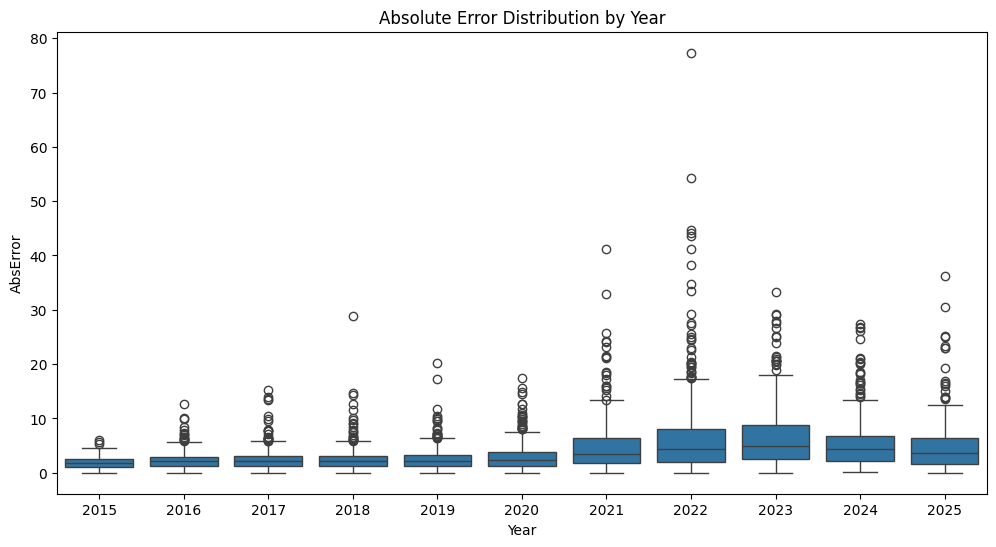

In [7]:
# C. Error Slicing by Year
error_df = pd.DataFrame({
    'Year': test_meta['year'],
    'Residual': residuals.values,
    'AbsError': np.abs(residuals.values)
})

plt.figure(figsize=(12, 6))
sns.boxplot(x='Year', y='AbsError', data=error_df)
plt.title('Absolute Error Distribution by Year')
plt.savefig('../reports/figures/error_by_year.png')
plt.show()

In [8]:
# 2. Explainability
print("\nGenerating Explanations...")
# A. Coefficients
coef_df = get_linear_coefficients(model, feature_names)
print("Top Coefficients:")
display(coef_df.head())
coef_df.to_csv('../reports/tables/ridge_coefficients.csv', index=False)


Generating Explanations...
Top Coefficients:


,Feature,Coefficient,AbsCoefficient
0,hpi_lag_1,68.600255,68.600255
2,hpi_lag_4,-9.386240,9.386240
3,qoq_growth,5.384825,5.384825
1,hpi_lag_2,-4.892055,4.892055
4,yoy_growth,-2.960349,2.960349


In [9]:
# B. Permutation Importance
perm_imp = calculate_permutation_importance(model, X_test, y_test)
print("\nPermutation Importance:")
display(perm_imp.head())
perm_imp.to_csv('../reports/tables/permutation_importance.csv', index=False)

print("\nFinal Evaluation Complete. Artifacts in reports/")


Permutation Importance:


,Feature,Importance,Std
0,hpi_lag_1,3.140521,0.050597
2,hpi_lag_4,0.055069,0.000814
1,hpi_lag_2,0.016029,0.000285
3,qoq_growth,0.004824,0.000088
4,yoy_growth,0.000256,0.000030



Final Evaluation Complete. Artifacts in reports/
